# Mejora del modelo con variables avanzadas

Este cuaderno incorpora las señales encontradas en el EDA y compara el resultado con la línea base usando exactamente la misma validación temporal.

In [1]:
from pathlib import Path
import sys

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

ROOT_DIR = Path.cwd().resolve()
if not (ROOT_DIR / 'src').exists():
    ROOT_DIR = ROOT_DIR.parent
sys.path.insert(0, str(ROOT_DIR / 'src'))

from config import FIGURES_DIR, MODELS_DIR, TABLES_DIR
from modelo import (
    crear_pipeline_linea_base,
    crear_pipeline_mejorado,
    crear_variables_avanzadas,
    dividir_temporalmente,
    evaluar_auc,
    guardar_modelo,
    tabla_coeficientes,
)
from preprocesamiento import cargar_dataset_modelo

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

## Variables agregadas

Se agregan tasas por tiempo de historial, proporciones de compras relacionadas con la oferta, recencia relativa y una bandera para clientes con volumen extremo. Las colas largas se comprimen con una transformación logarítmica con signo.

In [2]:
dataset = crear_variables_avanzadas(cargar_dataset_modelo())
division = dividir_temporalmente(dataset, proporcion_validacion=0.20)
train = division.entrenamiento
validacion = division.validacion

dataset[[
    'visitas_por_30d',
    'compras_por_visita',
    'gasto_por_30d',
    'proporcion_compras_categoria',
    'proporcion_compras_producto',
    'recencia_categoria_relativa',
    'lineas_por_30d',
    'volumen_extremo',
]].describe().T

,count,mean,std,min,25%,50%,75%,max
visitas_por_30d,160057.0,6.381059,3.812639,0.165886,3.766566,5.508190,8.106736,3.044000e+01
compras_por_visita,160057.0,13.650598,29.771587,1.000000,7.927419,11.655172,16.840000,6.332298e+03
gasto_por_30d,160057.0,447.093026,12999.845083,-440.948211,168.171356,289.569419,449.130831,3.527366e+06
proporcion_compras_categoria,160057.0,0.006693,0.013577,0.000000,0.000000,0.000987,0.008197,1.000000e+00
proporcion_compras_producto,160057.0,0.000542,0.003414,0.000000,0.000000,0.000000,0.000000,1.000000e+00
recencia_categoria_relativa,87418.0,0.258052,0.277639,0.002364,0.043269,0.131105,0.410040,1.000000e+00
lineas_por_30d,160057.0,92.290396,885.750166,0.380500,41.574632,71.268831,109.656476,1.932366e+05
volumen_extremo,160057.0,0.001006,0.031700,0.000000,0.000000,0.000000,0.000000,1.000000e+00


## Entrenamiento y comparación temporal

In [3]:
ruta_base = MODELS_DIR / '05_regresion_logistica_linea_base.joblib'
linea_base = joblib.load(ruta_base)
evaluacion_base = evaluar_auc(linea_base, validacion)

modelo_mejorado = crear_pipeline_mejorado(train)
modelo_mejorado.fit(train, train['repeater'].astype(int))
evaluacion_mejorada = evaluar_auc(modelo_mejorado, validacion)
guardar_modelo(modelo_mejorado, MODELS_DIR / '06_regresion_logistica_mejorada.joblib')

comparacion = pd.DataFrame([
    {'modelo': 'linea_base', 'auc_validacion_temporal': evaluacion_base['auc']},
    {'modelo': 'variables_avanzadas', 'auc_validacion_temporal': evaluacion_mejorada['auc']},
])
comparacion['mejora_frente_base'] = comparacion['auc_validacion_temporal'] - evaluacion_base['auc']
comparacion.to_csv(TABLES_DIR / '06_comparacion_modelos.csv', index=False)
comparacion

,modelo,auc_validacion_temporal,mejora_frente_base
0,linea_base,0.561354,0.000000
1,variables_avanzadas,0.644641,0.083287


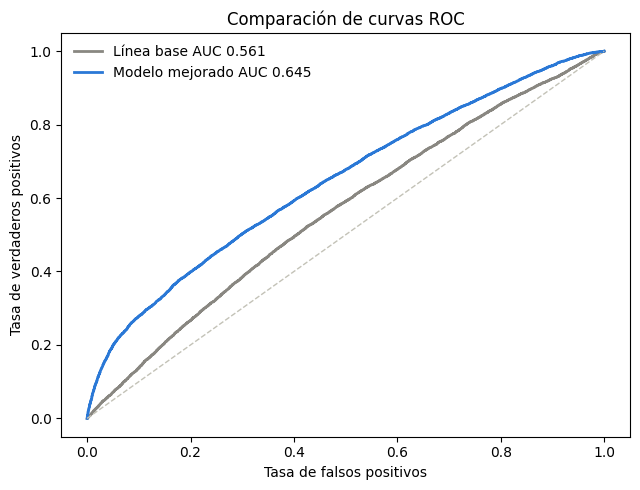

In [4]:
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.plot(evaluacion_base['fpr'], evaluacion_base['tpr'], color='#898781', linewidth=2, label=f"Línea base AUC {evaluacion_base['auc']:.3f}")
ax.plot(evaluacion_mejorada['fpr'], evaluacion_mejorada['tpr'], color='#2a78d6', linewidth=2, label=f"Modelo mejorado AUC {evaluacion_mejorada['auc']:.3f}")
ax.plot([0, 1], [0, 1], color='#c3c2b7', linestyle='--', linewidth=1)
ax.set_xlabel('Tasa de falsos positivos')
ax.set_ylabel('Tasa de verdaderos positivos')
ax.set_title('Comparación de curvas ROC')
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '06_comparacion_curvas_roc.png', dpi=150, bbox_inches='tight')
plt.show()

## Variables con mayor peso

Los coeficientes se usan para describir qué variables cambian más el resultado del modelo. Los identificadores siguen siendo anónimos y no reciben una interpretación comercial.

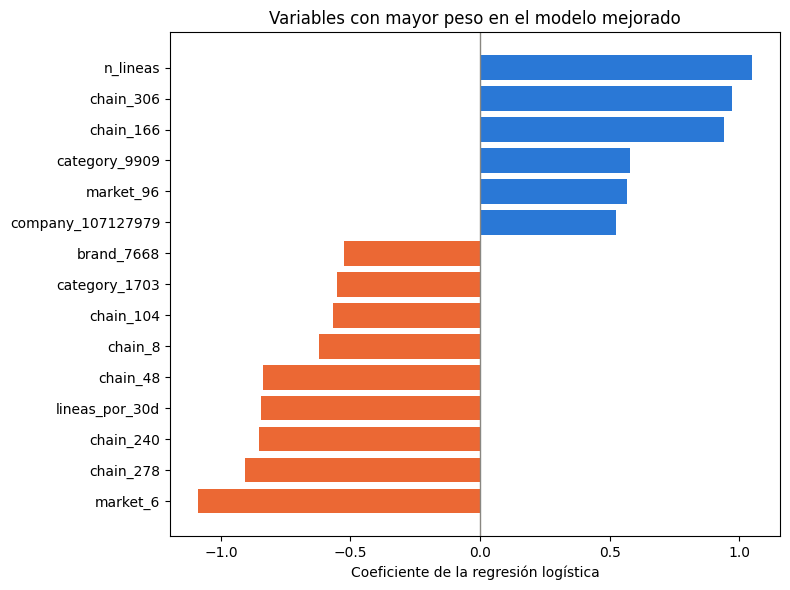

,variable,coeficiente,magnitud
0,market_6,-1.088835,1.088835
4,chain_278,-0.906780,0.906780
5,chain_240,-0.851175,0.851175
6,lineas_por_30d,-0.845472,0.845472
7,chain_48,-0.837227,0.837227
8,chain_8,-0.620883,0.620883
10,chain_104,-0.566659,0.566659
12,category_1703,-0.552722,0.552722
13,brand_7668,-0.525787,0.525787
14,company_107127979,0.522579,0.522579


In [5]:
coeficientes = tabla_coeficientes(modelo_mejorado)
coeficientes.to_csv(TABLES_DIR / '06_coeficientes_modelo_mejorado.csv', index=False)
top = coeficientes.head(15).sort_values('coeficiente')

fig, ax = plt.subplots(figsize=(8, 6))
colores = ['#eb6834' if valor < 0 else '#2a78d6' for valor in top['coeficiente']]
ax.barh(top['variable'], top['coeficiente'], color=colores)
ax.axvline(0, color='#898781', linewidth=1)
ax.set_xlabel('Coeficiente de la regresión logística')
ax.set_title('Variables con mayor peso en el modelo mejorado')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '06_coeficientes_principales.png', dpi=150, bbox_inches='tight')
plt.show()
top

## Comprobación con ofertas separadas

Esta revisión adicional reserva ofertas completas. Sirve para medir qué ocurre cuando una oferta de validación no apareció durante el entrenamiento, que es una diferencia importante entre train y test.

In [6]:
separador = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
indices_train, indices_validacion = next(separador.split(dataset, dataset['repeater'], groups=dataset['offer']))
train_ofertas = dataset.iloc[indices_train].copy()
validacion_ofertas = dataset.iloc[indices_validacion].copy()

base_ofertas = crear_pipeline_linea_base()
base_ofertas.fit(train_ofertas, train_ofertas['repeater'].astype(int))
mejorado_ofertas = crear_pipeline_mejorado(train_ofertas)
mejorado_ofertas.fit(train_ofertas, train_ofertas['repeater'].astype(int))

validacion_ofertas_tabla = pd.DataFrame([
    {
        'modelo': 'linea_base',
        'auc_ofertas_separadas': evaluar_auc(base_ofertas, validacion_ofertas)['auc'],
        'ofertas_entrenamiento': train_ofertas['offer'].nunique(),
        'ofertas_validacion': validacion_ofertas['offer'].nunique(),
    },
    {
        'modelo': 'variables_avanzadas',
        'auc_ofertas_separadas': evaluar_auc(mejorado_ofertas, validacion_ofertas)['auc'],
        'ofertas_entrenamiento': train_ofertas['offer'].nunique(),
        'ofertas_validacion': validacion_ofertas['offer'].nunique(),
    },
])
validacion_ofertas_tabla.to_csv(TABLES_DIR / '06_validacion_ofertas_separadas.csv', index=False)
validacion_ofertas_tabla

,modelo,auc_ofertas_separadas,ofertas_entrenamiento,ofertas_validacion
0,linea_base,0.459172,19,5
1,variables_avanzadas,0.669003,19,5


## Resultado

La comparación principal usa el corte temporal. La comprobación por oferta se presenta por separado porque responde una pregunta distinta y ayuda a medir el cambio entre los archivos de entrenamiento y prueba.